In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
 
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
 
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
# ======================================================================
# STEP 1: EXPLORATORY DATA ANALYSIS (EDA)
# ======================================================================
 
# --- Load data ---
df = pd.read_csv("monthly_milk_production (1).csv")
df

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727
...,...,...
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797


In [5]:
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m")
df.set_index("Date", inplace=True)
df.sort_index(inplace=True)

In [6]:
print("Shape:", df.shape)

Shape: (168, 1)


In [7]:
print(df.head())

            Production
Date                  
1962-01-01         589
1962-02-01         561
1962-03-01         640
1962-04-01         656
1962-05-01         727


In [8]:
print(df.describe())

       Production
count  168.000000
mean   754.708333
std    102.204524
min    553.000000
25%    677.750000
50%    761.000000
75%    824.500000
max    969.000000


In [9]:
# --- Check for missing values ---
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 Production    0
dtype: int64


In [10]:
df.isnull

<bound method DataFrame.isnull of             Production
Date                  
1962-01-01         589
1962-02-01         561
1962-03-01         640
1962-04-01         656
1962-05-01         727
...                ...
1975-08-01         858
1975-09-01         817
1975-10-01         827
1975-11-01         797
1975-12-01         843

[168 rows x 1 columns]>

In [11]:
# --- Check for outliers using IQR ---
Q1 = df["Production"].quantile(0.25)
Q3 = df["Production"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df["Production"] < lower_bound) | (df["Production"] > upper_bound)]
print(f"\nNumber of outliers detected (IQR method): {len(outliers)}")


Number of outliers detected (IQR method): 0


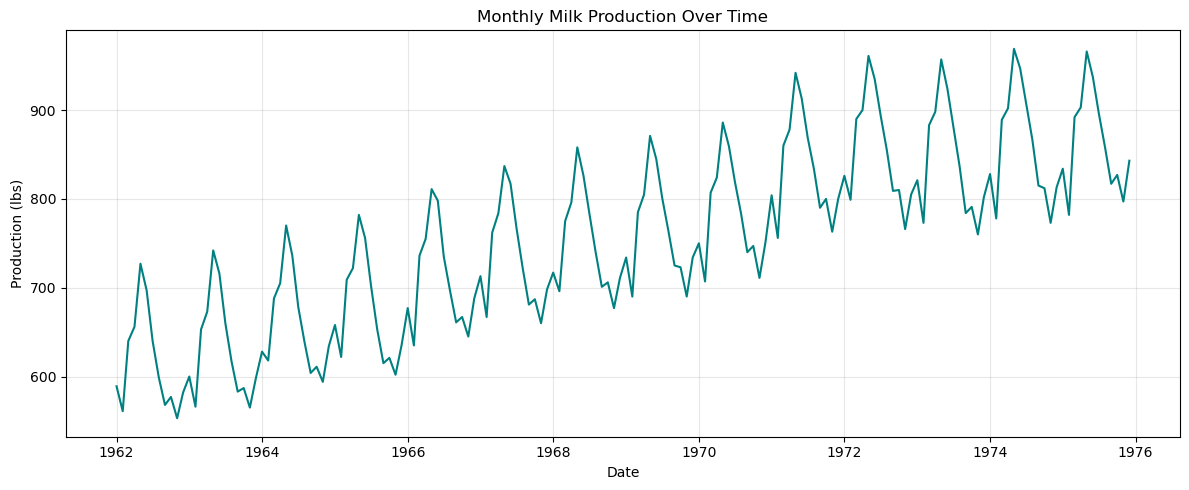

In [12]:
#--- Visualize the raw trend ---
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Production"], color="teal")
plt.title("Monthly Milk Production Over Time")
plt.xlabel("Date")
plt.ylabel("Production (lbs)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("01_trend_plot.png")
plt.show()

<Figure size 1200x500 with 0 Axes>

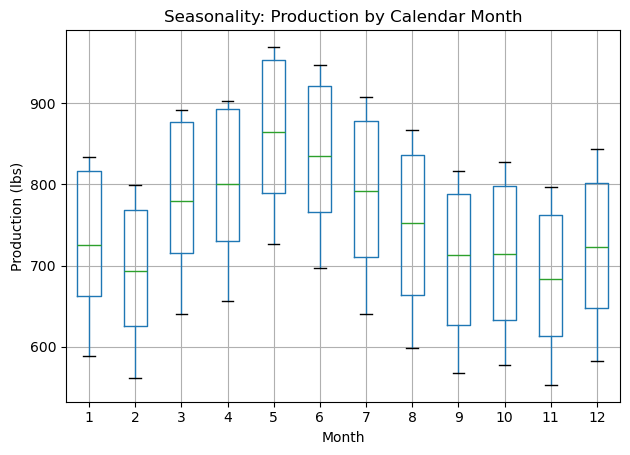

In [13]:
# --- Visualize seasonality: boxplot by calendar month ---
df["Month"] = df.index.month
plt.figure(figsize=(12, 5))
df.boxplot(column="Production", by="Month")
plt.title("Seasonality: Production by Calendar Month")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("Production (lbs)")
plt.tight_layout()
plt.savefig("02_seasonality_boxplot.png")
plt.show()

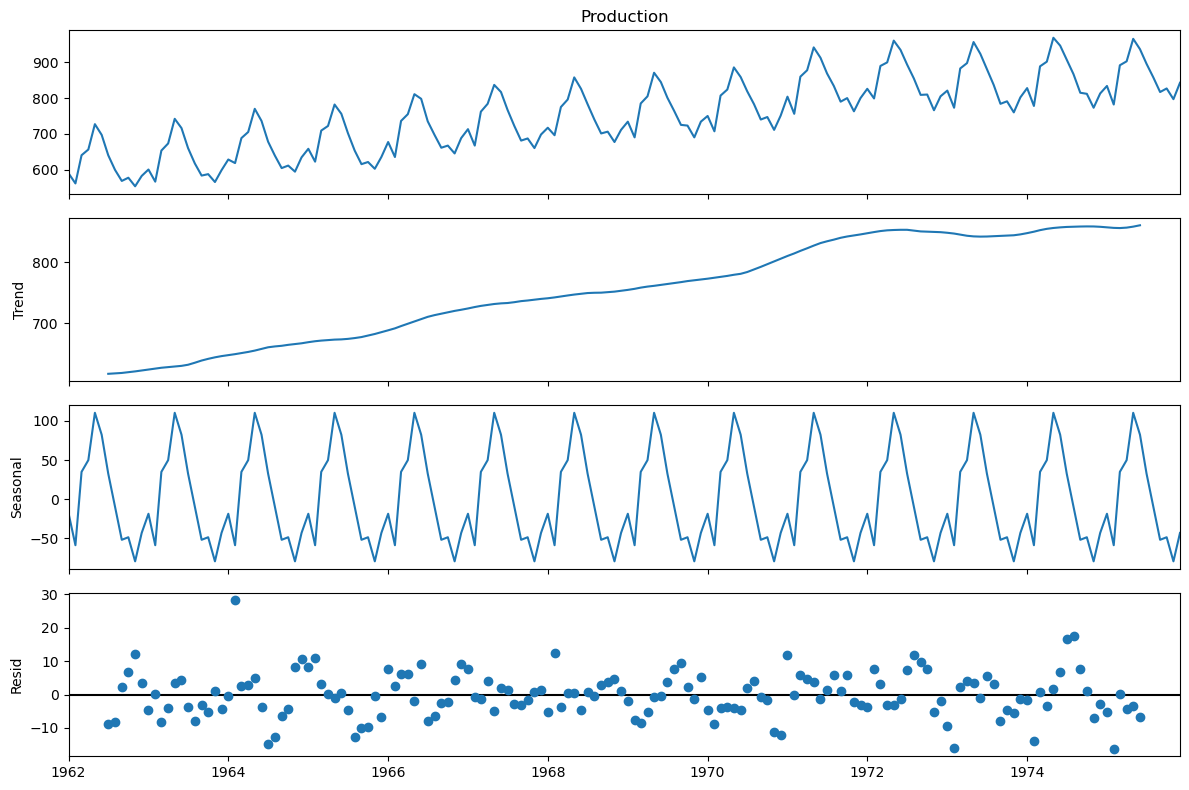

In [14]:
# --- Decompose the series into trend / seasonal / residual ---
from statsmodels.tsa.seasonal import seasonal_decompose
 
decomposition = seasonal_decompose(df["Production"], model="additive", period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.savefig("03_decomposition.png")
plt.show()

In [15]:
df.drop(columns=["Month"], inplace=True)

In [16]:
# ======================================================================
# STEP 2: DATA PREPARATION FOR DEEP LEARNING
# ======================================================================
 
# --- Train / validation / test split (chronological, no shuffling) ---
values = df["Production"].values.reshape(-1, 1)
n = len(values)
 
train_size = int(n * 0.70)
val_size = int(n * 0.15)
 
train_raw = values[:train_size]
val_raw = values[train_size: train_size + val_size]
test_raw = values[train_size + val_size:]
 
print(f"\nTrain size: {len(train_raw)}, Val size: {len(val_raw)}, Test size: {len(test_raw)}")


Train size: 117, Val size: 25, Test size: 26


In [17]:
# --- Scale the data (fit scaler ONLY on training data to avoid leakage) ---
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_raw)
val_scaled = scaler.transform(val_raw)
test_scaled = scaler.transform(test_raw)

In [18]:

# --- Create input-output sequences (sliding window) ---
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i: i + window_size, 0])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)
 
 
WINDOW_SIZE = 12  # use past 12 months to predict the next month
 
# To predict validation/test properly, prepend the last WINDOW_SIZE points
# of the previous split so we don't lose the first few sequences.
val_input = np.concatenate([train_scaled[-WINDOW_SIZE:], val_scaled])
test_input = np.concatenate([val_scaled[-WINDOW_SIZE:], test_scaled])
 
X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_val, y_val = create_sequences(val_input, WINDOW_SIZE)
X_test, y_test = create_sequences(test_input, WINDOW_SIZE)

# --- Reshape for RNN input: (samples, timesteps, features) ---
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
 
print(f"X_train shape: {X_train.shape}, X_val shape: {X_val.shape}, X_test shape: {X_test.shape}")

X_train shape: (105, 12, 1), X_val shape: (25, 12, 1), X_test shape: (26, 12, 1)


In [19]:
# ======================================================================
# STEP 3: MODEL BUILDING (RNN, LSTM, GRU)
# ======================================================================
 
def build_model(layer_type, units=64, window_size=WINDOW_SIZE, dropout=0.2):
    """Build a single-layer recurrent model. layer_type: 'RNN', 'LSTM', or 'GRU'."""
    layer_map = {"RNN": SimpleRNN, "LSTM": LSTM, "GRU": GRU}
    RecurrentLayer = layer_map[layer_type]
 
    model = Sequential([
        Input(shape=(window_size, 1)),
        RecurrentLayer(units, activation="tanh"),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model
 
 
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
 
EPOCHS = 100
BATCH_SIZE = 16
 
histories = {}
models = {}
 
for name in ["RNN", "LSTM", "GRU"]:
    print(f"\n--- Training {name} model ---")
    model = build_model(name)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )
    models[name] = model
    histories[name] = history



--- Training RNN model ---

--- Training LSTM model ---

--- Training GRU model ---


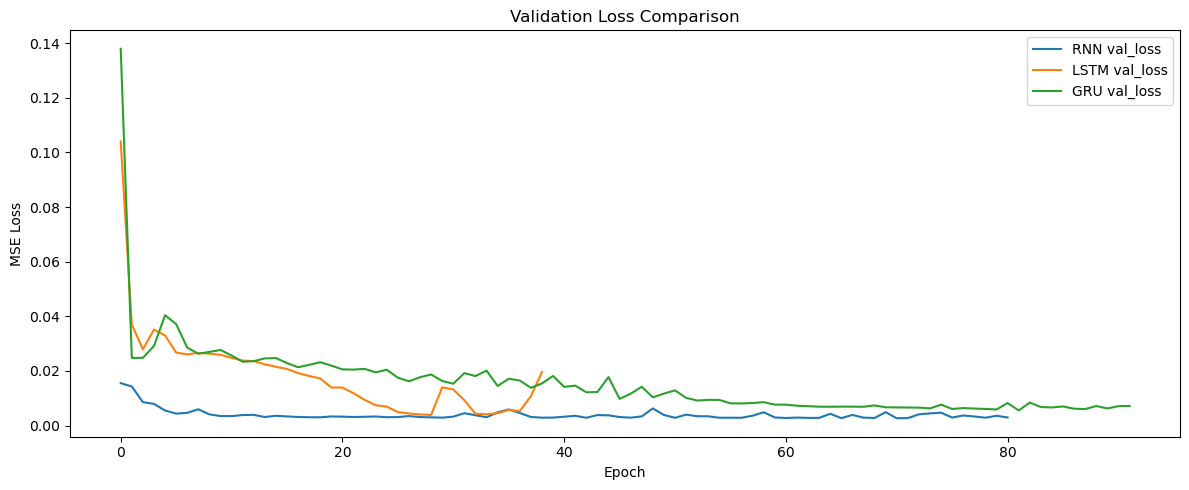

In [20]:
# --- Plot training/validation loss for each model ---
plt.figure(figsize=(12, 5))
for name in models:
    plt.plot(histories[name].history["val_loss"], label=f"{name} val_loss")
plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.savefig("04_val_loss_comparison.png")
plt.show()

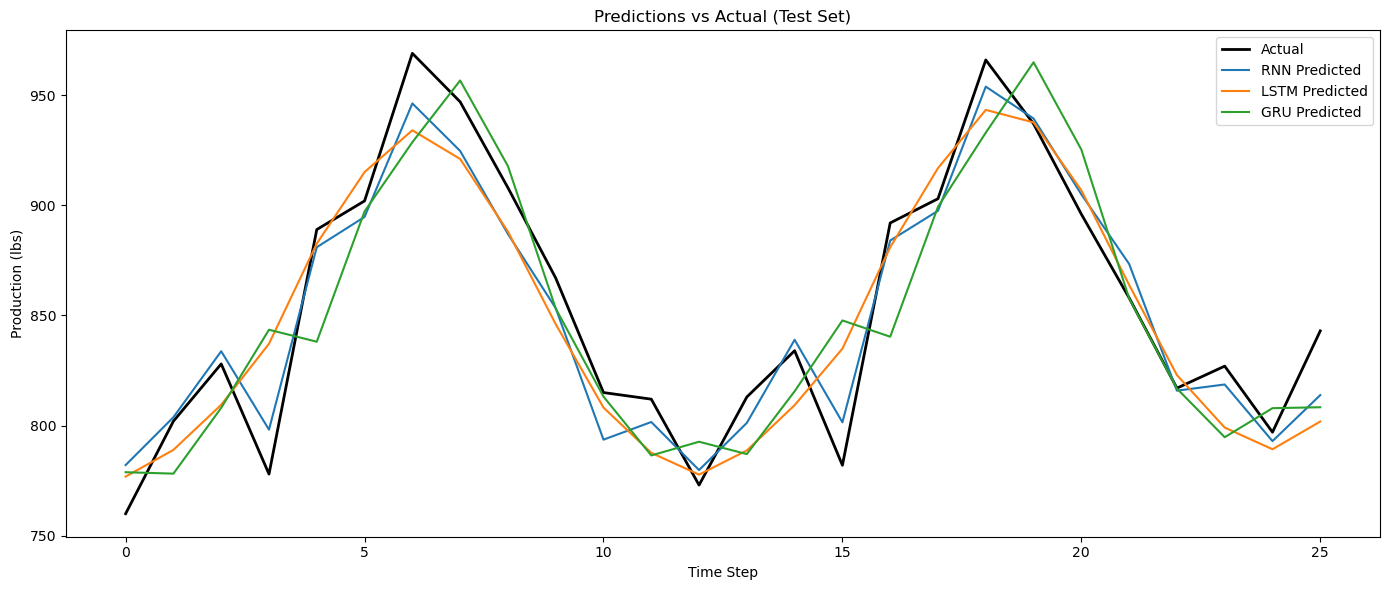

In [33]:

# ======================================================================
# STEP 4: MODEL EVALUATION
# ======================================================================
 
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
 
 
results = {}
 
plt.figure(figsize=(14, 6))
plt.plot(scaler.inverse_transform(y_test.reshape(-1, 1)), label="Actual", color="black", linewidth=2)
 
for name, model in models.items():
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test.reshape(-1, 1))
 
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mp = mape(y_true, y_pred)
 
    results[name] = {"RMSE": rmse, "MAE": mae, "MAPE": mp}
    plt.plot(y_pred, label=f"{name} Predicted")
 
plt.title("Predictions vs Actual (Test Set)")
plt.xlabel("Time Step")
plt.ylabel("Production (lbs)")
plt.legend()
plt.tight_layout()
plt.savefig("05_predictions_vs_actual.png")
plt.show()

In [34]:
results_df = pd.DataFrame(results).T
print("\nModel Comparison:\n", results_df)
 
best_model_name = results_df["RMSE"].idxmin()
print(f"\nBest performing model based on RMSE: {best_model_name}")


Model Comparison:
            RMSE        MAE      MAPE
RNN   14.337554  12.100199  1.421313
LSTM  24.377185  19.780654  2.346636
GRU   30.626791  24.558791  2.900951

Best performing model based on RMSE: RNN


In [35]:
# ======================================================================
# STEP 5: PREDICTION AND VISUALIZATION (Forecast next 12 months)
# ======================================================================
 
def forecast_future(model, last_window, n_steps=12):
    """Iteratively forecast n_steps ahead using the trained model."""
    forecast_scaled = []
    current_window = last_window.copy()  # shape: (window_size, 1)
 
    for _ in range(n_steps):
        input_seq = current_window.reshape(1, current_window.shape[0], 1)
        next_pred = model.predict(input_seq, verbose=0)[0, 0]
        forecast_scaled.append(next_pred)
        current_window = np.append(current_window[1:], [[next_pred]], axis=0)
 
    forecast_scaled = np.array(forecast_scaled).reshape(-1, 1)
    return scaler.inverse_transform(forecast_scaled)
 
 
best_model = models[best_model_name]
last_window = test_input[-WINDOW_SIZE:].reshape(WINDOW_SIZE, 1)
forecast = forecast_future(best_model, last_window, n_steps=12)
 
future_dates = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=12, freq="MS")
forecast_df = pd.DataFrame({"Date": future_dates, "Forecast": forecast.flatten()})
print("\n12-Month Forecast:\n", forecast_df)


12-Month Forecast:
          Date    Forecast
0  1976-01-01  847.894104
1  1976-02-01  806.288025
2  1976-03-01  887.766541
3  1976-04-01  896.868652
4  1976-05-01  948.613647
5  1976-06-01  929.387634
6  1976-07-01  896.686646
7  1976-08-01  868.456970
8  1976-09-01  821.796265
9  1976-10-01  833.117310
10 1976-11-01  811.468384
11 1976-12-01  840.063171


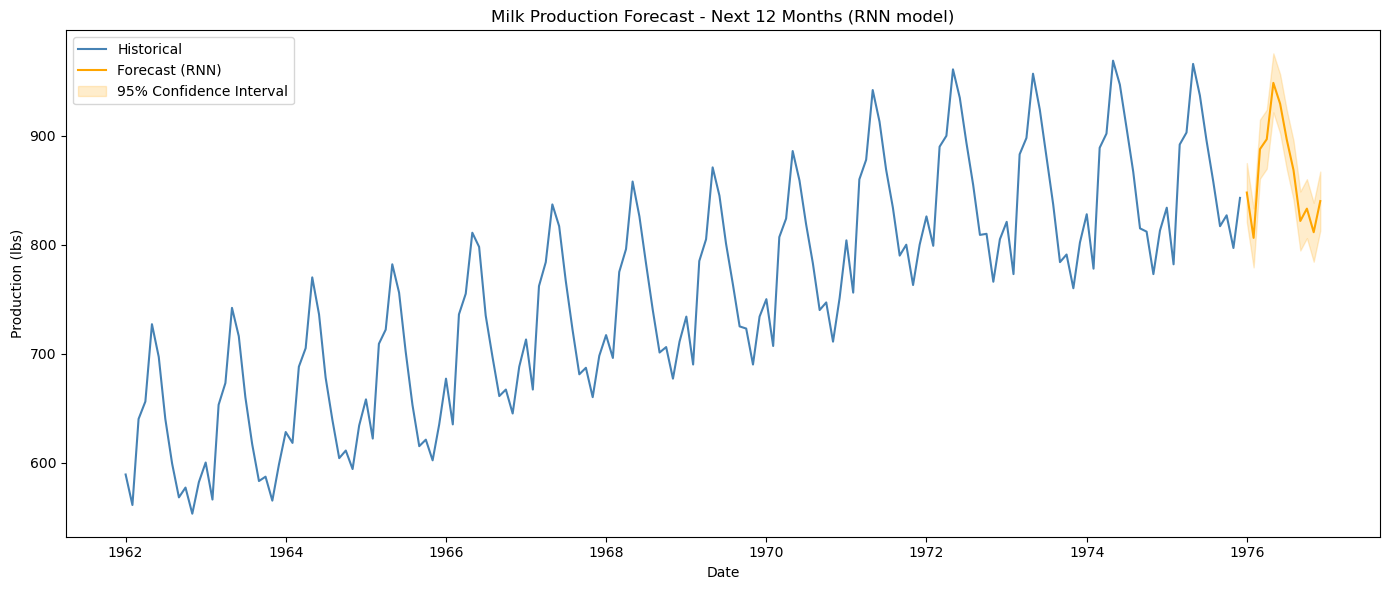

In [36]:
# --- Approximate confidence interval using residual std on test set ---
y_pred_scaled = best_model.predict(X_test, verbose=0)
y_pred_best = scaler.inverse_transform(y_pred_scaled)
y_true_best = scaler.inverse_transform(y_test.reshape(-1, 1))
residual_std = np.std(y_true_best - y_pred_best)
 
forecast_df["Lower_CI"] = forecast_df["Forecast"] - 1.96 * residual_std
forecast_df["Upper_CI"] = forecast_df["Forecast"] + 1.96 * residual_std
 
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Production"], label="Historical", color="steelblue")
plt.plot(forecast_df["Date"], forecast_df["Forecast"], label=f"Forecast ({best_model_name})", color="orange")
plt.fill_between(forecast_df["Date"], forecast_df["Lower_CI"], forecast_df["Upper_CI"],
                  color="orange", alpha=0.2, label="95% Confidence Interval")
plt.title(f"Milk Production Forecast - Next 12 Months ({best_model_name} model)")
plt.xlabel("Date")
plt.ylabel("Production (lbs)")
plt.legend()
plt.tight_layout()
plt.savefig("06_future_forecast.png")
plt.show()

In [37]:
# ======================================================================
# STEP 6: BUSINESS INSIGHTS
# ======================================================================
 
print("""
BUSINESS INSIGHTS
------------------
1. The milk production series shows a clear upward trend over the years, together
   with a repeating yearly (12-month) seasonal pattern - production peaks around
   May-June and dips around November-December.
2. The {best} model produced the lowest forecasting error (RMSE = {rmse:.2f},
   MAE = {mae:.2f}, MAPE = {mape:.2f}%), and is recommended for operational forecasting.
3. Using the 12-month forecast, the dairy business can:
   - Plan raw milk storage and cold-chain capacity ahead of seasonal peaks.
   - Schedule workforce and logistics (transport, packaging) to match expected
     production volume.
   - Negotiate supply contracts / distribution agreements using the forecast
     and its confidence interval rather than a single point estimate.
   - Flag months where actual production deviates strongly from the forecast
     as potential anomalies (equipment issues, herd health, weather shocks)
     requiring investigation.
""".format(
    best=best_model_name,
    rmse=results[best_model_name]["RMSE"],
    mae=results[best_model_name]["MAE"],
    mape=results[best_model_name]["MAPE"],
))
 
print("Script complete. Plots saved as PNG files in the working directory.")


BUSINESS INSIGHTS
------------------
1. The milk production series shows a clear upward trend over the years, together
   with a repeating yearly (12-month) seasonal pattern - production peaks around
   May-June and dips around November-December.
2. The RNN model produced the lowest forecasting error (RMSE = 14.34,
   MAE = 12.10, MAPE = 1.42%), and is recommended for operational forecasting.
3. Using the 12-month forecast, the dairy business can:
   - Plan raw milk storage and cold-chain capacity ahead of seasonal peaks.
   - Schedule workforce and logistics (transport, packaging) to match expected
     production volume.
   - Negotiate supply contracts / distribution agreements using the forecast
     and its confidence interval rather than a single point estimate.
   - Flag months where actual production deviates strongly from the forecast
     as potential anomalies (equipment issues, herd health, weather shocks)
     requiring investigation.

Script complete. Plots saved as PNG f